In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
fake_df=pd.read_csv("/content/Fake.csv")
true_df=pd.read_csv("/content/True.csv")

In [ ]:
fake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [ ]:
true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [ ]:
fake_df.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [ ]:
true_df.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [ ]:
print("duplicates in fake news",fake_df.duplicated().sum())
print("duplicates in true news",true_df.duplicated().sum())

duplicates in fake news 3
duplicates in true news 206


In [ ]:
fake_df=fake_df.drop_duplicates()

In [ ]:
true_df=true_df.drop_duplicates()

In [ ]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
true_df.shape

(21211, 4)

In [ ]:
fake_df.shape

(23478, 4)

In [ ]:
fake_df["label"] = 0
true_df["label"] = 1

In [ ]:
fake_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
true_df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [ ]:
df = pd.concat([fake_df, true_df], ignore_index=True)

In [ ]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
df.tail()

,title,text,subject,date,label
44684,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
44685,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
44686,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
44687,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
44688,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


In [ ]:
df.shape

(44689, 5)

In [ ]:
print(df["label"].value_counts())

label
0    23478
1    21211
Name: count, dtype: int64


EDA

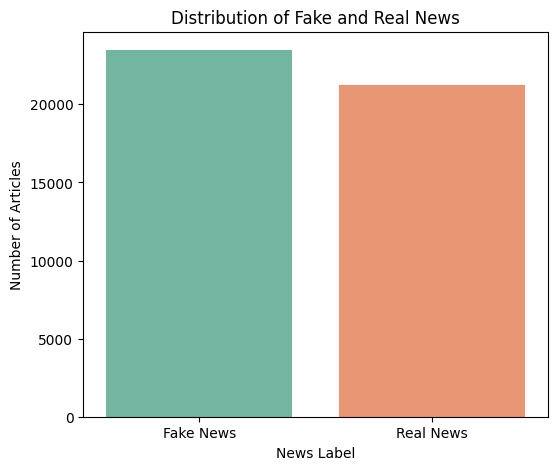

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="label",
    palette="Set2"
)

plt.title("Distribution of Fake and Real News")
plt.xlabel("News Label")
plt.ylabel("Number of Articles")

plt.xticks([0,1], ["Fake News","Real News"])

plt.show()

In [ ]:
class_percentage = df["label"].value_counts(normalize=True) * 100
print(class_percentage)

label
0    52.536418
1    47.463582
Name: proportion, dtype: float64


In [ ]:
print("Unique Subjects:")
print(df["subject"].unique())

print("\nNumber of Unique Subjects:", df["subject"].nunique())

Unique Subjects:
['News' 'politics' 'Government News' 'left-news' 'US_News' 'Middle-east'
 'politicsNews' 'worldnews']

Number of Unique Subjects: 8


In [ ]:
subject_counts = df["subject"].value_counts()

print(subject_counts)

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


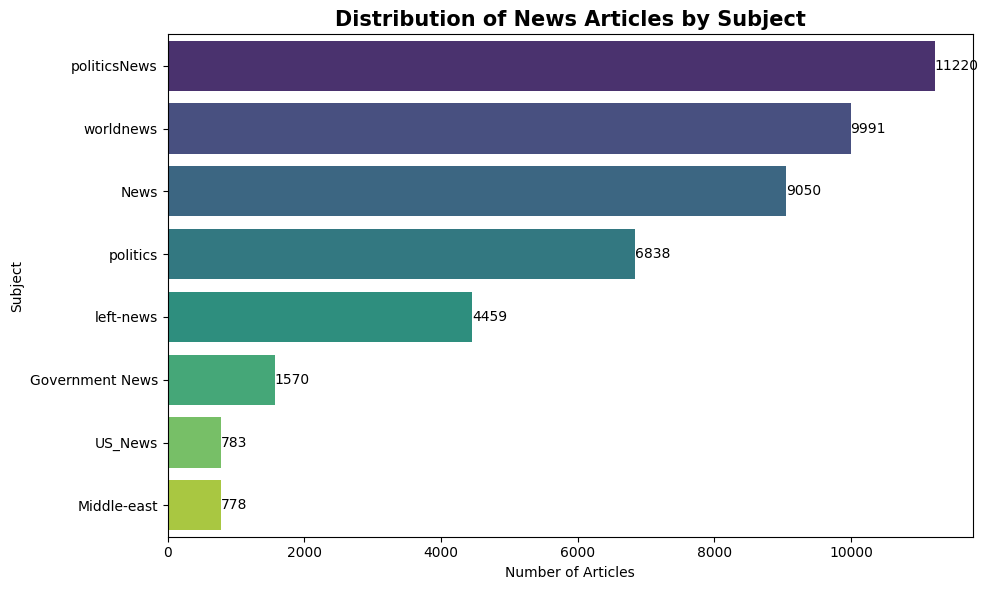

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    y="subject",
    order=df["subject"].value_counts().index,
    palette="viridis"
)

plt.title("Distribution of News Articles by Subject", fontsize=15, fontweight="bold")
plt.xlabel("Number of Articles")
plt.ylabel("Subject")

# Add value labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left',
                va='center',
                fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:

df["word_count"] = df["text"].apply(lambda x: len(x.split()))
average_words = df["word_count"].mean()
print(f"Average Article Length: {average_words:.2f} words")

Average Article Length: 404.97 words


In [ ]:
# Descriptive statistics for article length

df["word_count"].describe()

,word_count
count,44689.000000
mean,404.966502
std,351.573770
min,0.000000
25%,203.000000
50%,362.000000
75%,512.000000
max,8135.000000


In [ ]:
# Find articles with zero words

zero_word_articles = df[df["word_count"] == 0]

print("Number of zero-word articles:", len(zero_word_articles))

zero_word_articles[["title", "text", "label"]]

Number of zero-word articles: 631


,title,text,label
10922,TAKE OUR POLL: Who Do You Think President Trum...,,0
11040,Joe Scarborough BERATES Mika Brzezinski Over “...,,0
11189,WATCH TUCKER CARLSON Scorch Sanctuary City May...,,0
11224,MAYOR OF SANCTUARY CITY: Trump Trying To Make ...,,0
11235,SHOCKER: Public School Turns Computer Lab Into...,,0
...,...,...,...
21823,FULL VIDEO: THE BLOCKBUSTER INVESTIGATION INTO...,,0
21824,(VIDEO) HILLARY CLINTON: RELIGIOUS BELIEFS MUS...,,0
21854,(VIDEO)ICE PROTECTING OBAMA: WON’T RELEASE NAM...,,0
21870,(VIDEO) HYSTERICAL SNL TAKE ON HILLARY’S ANNOU...,,0


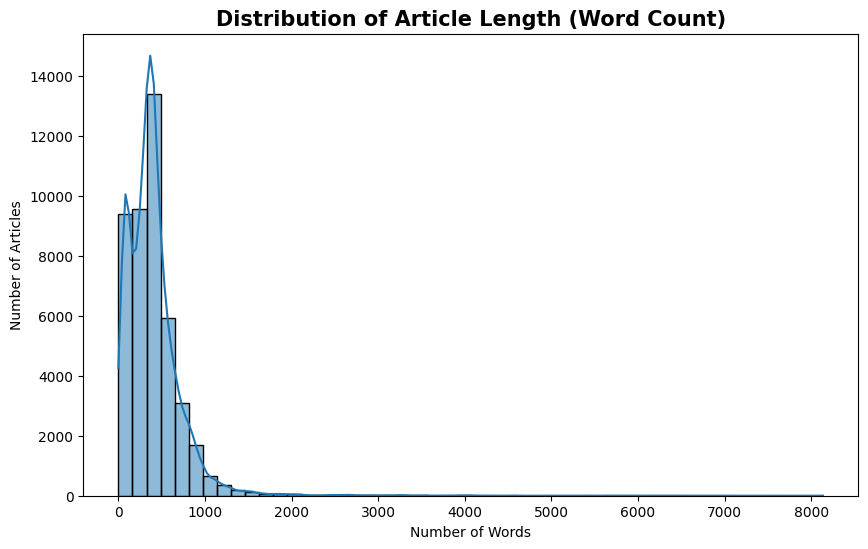

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df["word_count"], bins=50, kde=True)

plt.title("Distribution of Article Length (Word Count)", fontsize=15, fontweight="bold")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")

plt.show()

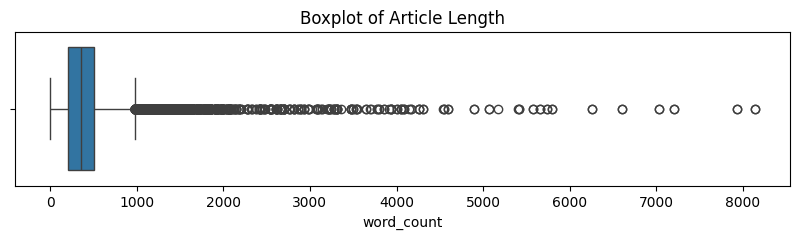

In [ ]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["word_count"])

plt.title("Boxplot of Article Length")

plt.show()

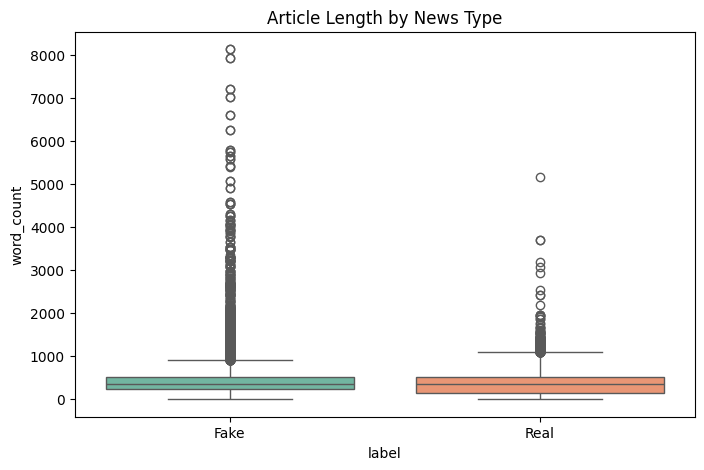

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="word_count",
    palette="Set2"
)

plt.xticks([0,1],["Fake","Real"])

plt.title("Article Length by News Type")

plt.show()

In [ ]:
df["title_word_count"] = df["title"].apply(lambda x: len(x.split()))

print(df["title_word_count"].describe())

count    44689.000000
mean        12.463246
std          4.116191
min          1.000000
25%         10.000000
50%         11.000000
75%         14.000000
max         42.000000
Name: title_word_count, dtype: float64


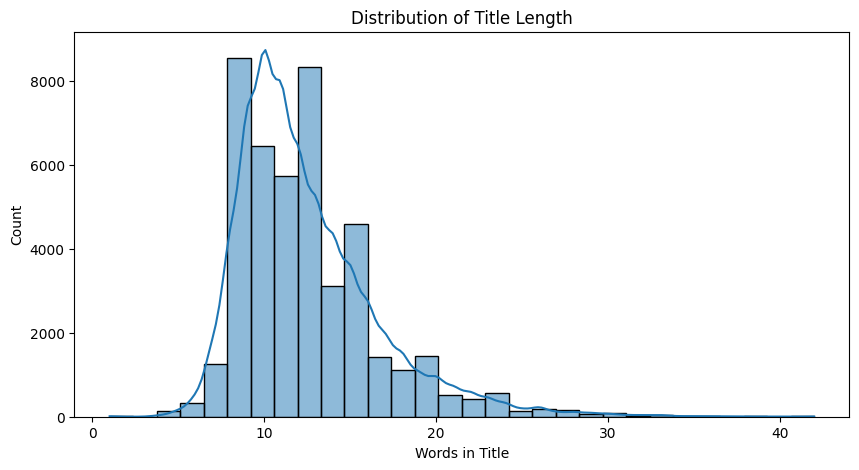

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["title_word_count"], bins=30, kde=True)

plt.title("Distribution of Title Length")

plt.xlabel("Words in Title")

plt.show()

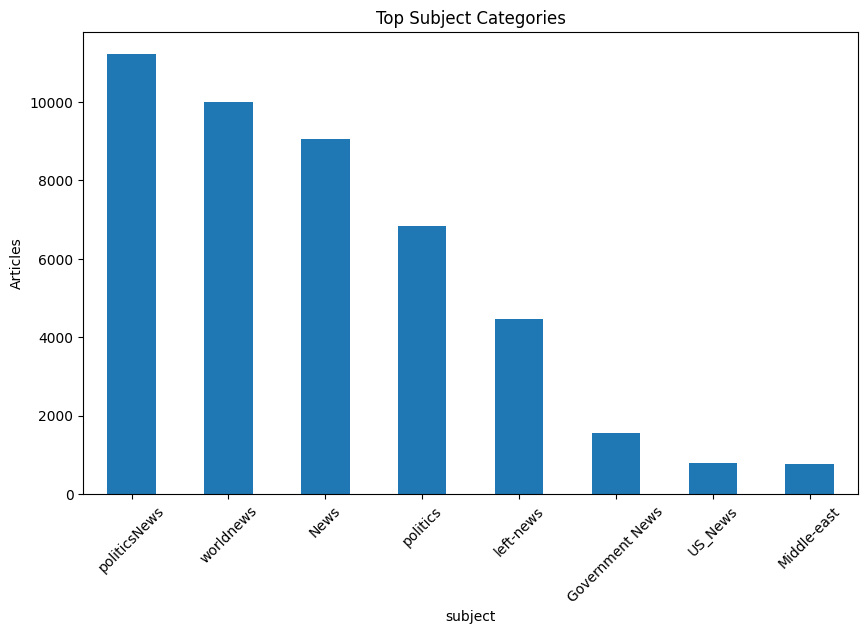

In [ ]:
plt.figure(figsize=(10,6))

df["subject"].value_counts().plot(kind="bar")

plt.title("Top Subject Categories")

plt.ylabel("Articles")

plt.xticks(rotation=45)

plt.show()

Feature Engineering


In [ ]:
# Combine title and article text

df["content"] = df["title"] + " " + df["text"]

# Display the new column
df[["title", "text", "content"]].head()

,title,text,content
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,Pope Francis Just Called Out Donald Trump Dur...


In [ ]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
# Initialize lemmatizer and stopwords

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

# Text preprocessing function

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

In [ ]:
df["clean_text"] = df["content"].apply(clean_text)

In [ ]:
df[["content", "clean_text"]].head()

,content,clean_text
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump sends embarrassing new year’s eve...
1,Drunk Bragging Trump Staffer Started Russian ...,drunk bragging trump staffer started russian c...
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clarke becomes internet joke thr...
3,Trump Is So Obsessed He Even Has Obama’s Name...,trump obsessed even obama’s name coded website...
4,Pope Francis Just Called Out Donald Trump Dur...,pope francis called donald trump christmas spe...


In [ ]:
# Compare original and cleaned text

sample = df[["content", "clean_text"]].head(5)

for i in range(len(sample)):
    print("="*100)
    print(f"Article {i+1}")
    print("\nOriginal Text:\n")
    print(sample.iloc[i]["content"][:500])   # Show first 500 characters

    print("\nCleaned Text:\n")
    print(sample.iloc[i]["clean_text"][:500])

    print("\n")

Article 1

Original Text:

 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, 

Cleaned Text:

donald trump sends embarrassing new year’s eve message disturbing donald trump wish american happy new year leave instead give shout enemy hater dishonest fake news medium former reality show star one job country rapidly grows stronger smarter want wish friend supporter enemy hater even dishonest fake news medium happy healthy new year president angry pant tweeted great year america country rapidly grows stronger smarter want wish friend supporter enem

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.7
)

X = tfidf.fit_transform(df["clean_text"])
y = df["label"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (44689, 10000)
Target Shape: (44689,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (35751, 10000)
Testing Shape : (8938, 10000)


In [ ]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = lr_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.9900425151040502
Precision: 0.9866416686196391
Recall   : 0.9924563884959925
F1 Score : 0.9895404865436597


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred_nb = nb_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

Accuracy : 0.9493175206981428
Precision: 0.9419174247725682
Recall   : 0.9519094766619519
F1 Score : 0.9468870911009497


In [ ]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95      4696
           1       0.94      0.95      0.95      4242

    accuracy                           0.95      8938
   macro avg       0.95      0.95      0.95      8938
weighted avg       0.95      0.95      0.95      8938



In [ ]:
from sklearn.svm import LinearSVC

# Initialize the model
svm_model = LinearSVC(random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

LinearSVC(random_state=42)

In [ ]:
# Predict on test data
y_pred_svm = svm_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

Accuracy : 0.9968673081226225
Precision: 0.9962317475270843
Recall   : 0.9971711456859972
F1 Score : 0.9967012252591895


In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.9982098903557843
Precision: 0.9978793590951932
Recall   : 0.9983498349834984
F1 Score : 0.998114541597926


In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

In [ ]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

Accuracy : 0.9975385992392034
Precision: 0.9964705882352941
Recall   : 0.9983498349834984
F1 Score : 0.9974093264248705


In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [ ]:
import pandas as pd

# Create an empty list
results = []

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr)
})

# Naive Bayes
results.append({
    "Model": "Naive Bayes",
    "Accuracy": accuracy_score(y_test, y_pred_nb),
    "Precision": precision_score(y_test, y_pred_nb),
    "Recall": recall_score(y_test, y_pred_nb),
    "F1 Score": f1_score(y_test, y_pred_nb)
})

# Linear SVM
results.append({
    "Model": "Linear SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm),
    "Recall": recall_score(y_test, y_pred_svm),
    "F1 Score": f1_score(y_test, y_pred_svm)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf)
})

# XGBoost
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb)
})

# Create DataFrame
comparison_df = pd.DataFrame(results)

# Sort by Accuracy
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.998210,0.997879,0.998350,0.998115
1,XGBoost,0.997539,0.996471,0.998350,0.997409
2,Linear SVM,0.996867,0.996232,0.997171,0.996701
3,Logistic Regression,0.990043,0.986642,0.992456,0.989540
4,Naive Bayes,0.949318,0.941917,0.951909,0.946887


In [ ]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    GRU,
    Bidirectional,
    Dense,
    Dropout
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
vocab_size = 10000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(df["clean_text"])

sequences = tokenizer.texts_to_sequences(df["clean_text"])

In [ ]:
print("Total Unique Words:", len(tokenizer.word_index))

Total Unique Words: 225080


In [ ]:
article_lengths = [len(seq) for seq in sequences]

print("Maximum Length:", max(article_lengths))
print("Average Length:", sum(article_lengths)/len(article_lengths))

Maximum Length: 4854
Average Length: 238.74709660095326


In [ ]:
max_length = 500

In [ ]:
X_dl = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print(X_dl.shape)

(44689, 500)


In [ ]:
from sklearn.model_selection import train_test_split

y_dl = df["label"].values

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl,
    y_dl,
    test_size=0.2,
    random_state=42,
    stratify=y_dl
)

print(X_train_dl.shape)
print(X_test_dl.shape)

(35751, 500)
(8938, 500)


In [ ]:
lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    ),

    LSTM(128),

    Dropout(0.5),

    Dense(64, activation="relu"),

    Dense(1, activation="sigmoid")
])

In [ ]:
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
lstm_model.build(input_shape=(None, max_length))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,419,905 (5.42 MB)

 Trainable params: 1,419,905 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm = lstm_model.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    verbose=1
)

Epoch 1/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.5272 - loss: 0.6932 - val_accuracy: 0.5445 - val_loss: 0.6857
Epoch 2/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.5503 - loss: 0.6710 - val_accuracy: 0.5575 - val_loss: 0.6602
Epoch 3/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.7151 - loss: 0.5370 - val_accuracy: 0.8999 - val_loss: 0.3401
Epoch 4/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.9027 - loss: 0.3165 - val_accuracy: 0.8842 - val_loss: 0.3256
Epoch 5/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.8880 - loss: 0.3379 - val_accuracy: 0.9074 - val_loss: 0.3058


In [ ]:
loss, accuracy = lstm_model.evaluate(
    X_test_dl,
    y_test_dl
)

print("Test Accuracy:", accuracy)

280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9074 - loss: 0.3075
Test Accuracy: 0.9073618054389954


In [ ]:
loss, test_accuracy = lstm_model.evaluate(X_test_dl, y_test_dl)

print("Test Loss :", loss)
print("Test Accuracy :", test_accuracy)

280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9074 - loss: 0.3075
Test Loss : 0.30750393867492676
Test Accuracy : 0.9073618054389954


In [ ]:
y_pred_prob_lstm = lstm_model.predict(X_test_dl)

y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int)

280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [ ]:
y_pred_lstm = y_pred_lstm.flatten()

In [ ]:
print(classification_report(y_test_dl, y_pred_lstm))

              precision    recall  f1-score   support

           0       0.95      0.87      0.91      4696
           1       0.87      0.95      0.91      4242

    accuracy                           0.91      8938
   macro avg       0.91      0.91      0.91      8938
weighted avg       0.91      0.91      0.91      8938



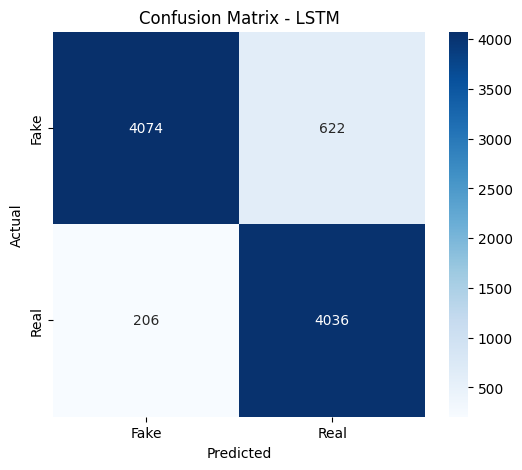

In [ ]:
cm = confusion_matrix(y_test_dl, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake","Real"],
    yticklabels=["Fake","Real"]
)

plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,393 (5.29 MB)

 Trainable params: 1,387,393 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.5316 - loss: 0.6912 - val_accuracy: 0.5427 - val_loss: 0.6864
Epoch 2/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.5454 - loss: 0.6741 - val_accuracy: 0.5606 - val_loss: 0.6606
Epoch 3/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.9021 - loss: 0.1955 - val_accuracy: 0.9961 - val_loss: 0.0196
Epoch 4/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9974 - loss: 0.0131 - val_accuracy: 0.9966 - val_loss: 0.0103
Epoch 5/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9993 - loss: 0.0043 - val_accuracy: 0.9962 - val_loss: 0.0165
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9956 - loss: 0.0166

Test Loss: 0.0166
Test Accuracy: 0.9956
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

Accuracy: 0.9956

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4696
           1       0.99      1.00      1.00   

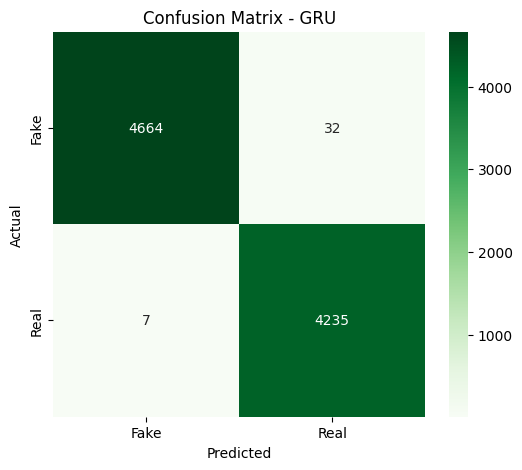

In [ ]:
# ============================
# GRU MODEL - COMPLETE PIPELINE
# ============================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Build GRU Model
gru_model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=128,
              input_length=max_length),

    GRU(128),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Compile
gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display Model Summary
gru_model.build(input_shape=(None, max_length))
gru_model.summary()

# Train Model
history_gru = gru_model.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    verbose=1
)

# Evaluate on Test Data
loss, test_accuracy = gru_model.evaluate(X_test_dl, y_test_dl, verbose=1)

print("\nTest Loss:", round(loss,4))
print("Test Accuracy:", round(test_accuracy,4))

# Predictions
y_pred_prob_gru = gru_model.predict(X_test_dl)

y_pred_gru = (y_pred_prob_gru > 0.5).astype(int).flatten()

# Accuracy
print("\nAccuracy:", round(accuracy_score(y_test_dl, y_pred_gru),4))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_dl, y_pred_gru))

# Confusion Matrix
cm = confusion_matrix(y_test_dl, y_pred_gru)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Fake','Real'],
    yticklabels=['Fake','Real']
)

plt.title("Confusion Matrix - GRU")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,559,681 (5.95 MB)

 Trainable params: 1,559,681 (5.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.9813 - loss: 0.0421 - val_accuracy: 0.9987 - val_loss: 0.0059
Epoch 2/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.9982 - val_loss: 0.0098
Epoch 3/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9983 - val_loss: 0.0078
Epoch 4/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.9998 - loss: 0.0010 - val_accuracy: 0.9990 - val_loss: 0.0071
Epoch 5/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.9998 - loss: 9.3459e-04 - val_accuracy: 0.9983 - val_loss: 0.0086
280/280 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9987 - loss: 0.0062

Test Loss: 0.0062
Test Accuracy: 0.9987
280/280 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step

Accuracy: 0.9987

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1

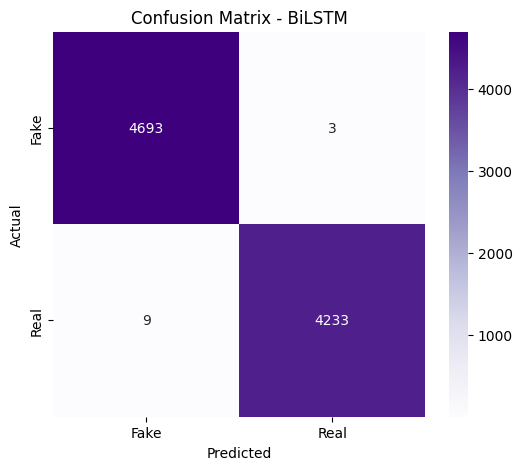

In [ ]:
# ===================================
# BiLSTM MODEL - COMPLETE PIPELINE
# ===================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Build BiLSTM Model
bilstm_model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    ),

    Bidirectional(LSTM(128)),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Compile Model
bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display Model Summary
bilstm_model.build(input_shape=(None, max_length))
bilstm_model.summary()

# Train Model
history_bilstm = bilstm_model.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    verbose=1
)

# Evaluate Model
loss, test_accuracy = bilstm_model.evaluate(
    X_test_dl,
    y_test_dl,
    verbose=1
)

print("\nTest Loss:", round(loss,4))
print("Test Accuracy:", round(test_accuracy,4))

# Predictions
y_pred_prob_bilstm = bilstm_model.predict(X_test_dl)

y_pred_bilstm = (y_pred_prob_bilstm > 0.5).astype(int).flatten()

# Accuracy
print("\nAccuracy:", round(accuracy_score(y_test_dl, y_pred_bilstm),4))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_dl, y_pred_bilstm))

# Confusion Matrix
cm = confusion_matrix(y_test_dl, y_pred_bilstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Fake','Real'],
    yticklabels=['Fake','Real']
)

plt.title("Confusion Matrix - BiLSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
import os

os.makedirs("saved_models", exist_ok=True)

In [ ]:
bilstm_model.save("saved_models/fake_news_model.keras")

In [ ]:
import pickle

with open("saved_models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [ ]:
config = {
    "vocab_size": vocab_size,
    "max_length": max_length
}

with open("saved_models/config.pkl", "wb") as f:
    pickle.dump(config, f)

In [ ]:
df.to_csv(
    "saved_models/clean_fake_news_dataset.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("saved_models/fake_news_model.keras")
files.download("saved_models/tokenizer.pkl")
files.download("saved_models/config.pkl")

files.download("saved_models/clean_fake_news_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>